# Fake News Detection using Naive Bayes

Member 02

ML Model: Multinomial Naive Bayes

Dataset: Fake and Real News Dataset

## Objective

The objective of this notebook is to develop and evaluate a Naive Bayes model for classifying news articles as Fake or Real.

In [1]:
import os
import re
import string
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK resources downloaded successfully.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...


NLTK resources downloaded successfully.


## 1. Data Collection and Loading

The Fake.csv and True.csv files are loaded separately.  
A label is assigned to each dataset:

- Fake News = 0
- Real News = 1

In [3]:
fake_path = "../data/Fake.csv"
true_path = "../data/True.csv"

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

print("Fake dataset shape:", fake_df.shape)
print("True dataset shape:", true_df.shape)

Fake dataset shape: (23481, 4)
True dataset shape: (21417, 4)


In [4]:
print("Fake News Dataset")
display(fake_df.head())

print("Real News Dataset")
display(true_df.head())

Fake News Dataset


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


Real News Dataset


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
print("Fake dataset columns:", fake_df.columns.tolist())
print("True dataset columns:", true_df.columns.tolist())

Fake dataset columns: ['title', 'text', 'subject', 'date']
True dataset columns: ['title', 'text', 'subject', 'date']


In [6]:
fake_df["label"] = 0
true_df["label"] = 1

print("Labels added successfully.")

Labels added successfully.


In [7]:
df = pd.concat([fake_df, true_df], ignore_index=True)

print("Combined dataset shape:", df.shape)
display(df.head())

Combined dataset shape: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


## 2. Initial Dataset Inspection

The dataset is inspected to identify:

- Number of records
- Available columns
- Data types
- Missing values
- Duplicate records
- Class distribution

In [8]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB

Missing Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicate Rows:
209


## 3. Handling Missing Values and Duplicate Records

The dataset contains no missing values. However, duplicate records can cause data leakage and affect model evaluation. Therefore, duplicate rows are removed before splitting the dataset.

In [9]:
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)
removed_rows = rows_before - rows_after

print("Rows before removing duplicates:", rows_before)
print("Duplicate rows removed:", removed_rows)
print("Rows after removing duplicates:", rows_after)

Rows before removing duplicates: 44898
Duplicate rows removed: 209
Rows after removing duplicates: 44689


## 4. Preparing the Text Column

The news title and article body are combined into a single text column named content. This allows the model to learn information from both the headline and the complete news article.

In [10]:
df["title"] = df["title"].fillna("").astype(str)
df["text"] = df["text"].fillna("").astype(str)

df["content"] = (
    df["title"].str.strip() + " " + df["text"].str.strip()
).str.strip()

print("Content column created successfully.")

display(df[["title", "text", "content", "label"]].head())

Content column created successfully.


,title,text,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Donald Trump Sends Out Embarrassing New Year’s...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Drunk Bragging Trump Staffer Started Russian C...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Sheriff David Clarke Becomes An Internet Joke ...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Trump Is So Obsessed He Even Has Obama’s Name ...,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Pope Francis Just Called Out Donald Trump Duri...,0


In [11]:
empty_content_count = (df["content"].str.strip() == "").sum()

print("Empty content records:", empty_content_count)

Empty content records: 0


## 5. Exploratory Data Analysis – Class Distribution

The class distribution is examined to determine whether the dataset is balanced between Fake and Real news articles.

- Label 0 represents Fake News
- Label 1 represents Real News

In [12]:
class_counts = df["label"].value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Label": [0, 1],
    "Class": ["Fake News", "Real News"],
    "Count": [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ]
})

class_distribution["Percentage"] = (
    class_distribution["Count"] / len(df) * 100
).round(2)

display(class_distribution)

,Label,Class,Count,Percentage
0,0,Fake News,23478,52.54
1,1,Real News,21211,47.46


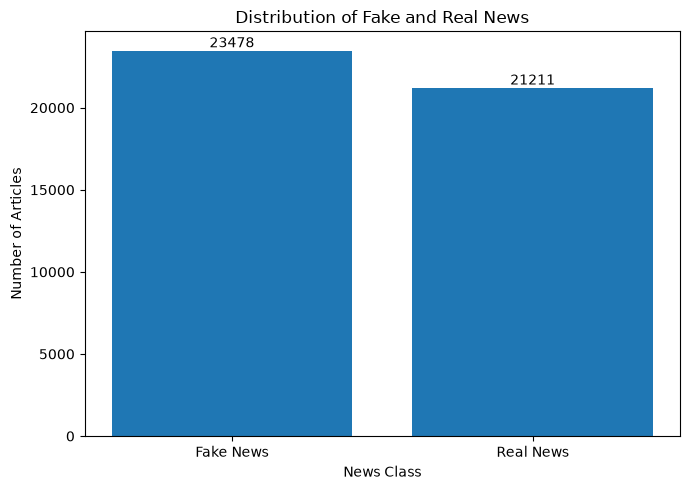

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    class_distribution["Class"],
    class_distribution["Count"]
)

plt.title("Distribution of Fake and Real News")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")

for index, value in enumerate(class_distribution["Count"]):
    plt.text(index, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 6. Dataset Shuffling

The combined dataset is shuffled to mix Fake and Real news records. A fixed random state is used to ensure reproducible results.

In [14]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shuffled successfully.")
display(df[["content", "label"]].head())

Dataset shuffled successfully.


,content,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,0
1,Kenya opposition leader calls for calm in slum...,1
2,Egypt rejects U.S. decision to move its embass...,1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,0
4,Trump Rally Nearly Turns Into A Full-Blown Rac...,0


## 7. Text Preprocessing

The following preprocessing operations are applied to the news content:

1. Convert text to lowercase
2. Remove URLs
3. Remove HTML tags
4. Remove punctuation and special characters
5. Tokenize the text
6. Remove English stop words
7. Lemmatize words
8. Remove unnecessary whitespace

In [15]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Clean and preprocess a news article.
    """

    # Ensure the input is a string
    text = str(text)

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove punctuation, numbers and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenization
    tokens = text.split()

    # Stop-word removal and lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    # Combine tokens back into one string
    cleaned_text = " ".join(cleaned_tokens)

    # Remove extra spaces
    cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

    return cleaned_text

print("Text preprocessing function created successfully.")

Text preprocessing function created successfully.


In [16]:
sample_text = """
BREAKING NEWS!!! Visit https://example.com for more information.
The politicians were making several claims in 2026.
"""

cleaned_sample = clean_text(sample_text)

print("Original Text:")
print(sample_text)

print("\nCleaned Text:")
print(cleaned_sample)

Original Text:

BREAKING NEWS!!! Visit https://example.com for more information.
The politicians were making several claims in 2026.


Cleaned Text:
breaking news visit information politician making several claim


In [17]:
preprocessing_preview = df[["content", "label"]].head().copy()

preprocessing_preview["cleaned_content"] = (
    preprocessing_preview["content"].apply(clean_text)
)

display(
    preprocessing_preview[
        ["content", "cleaned_content", "label"]
    ]
)


,content,cleaned_content,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,wow leftist librarian reject shipment child bo...,0
1,Kenya opposition leader calls for calm in slum...,kenya opposition leader call calm slum hit dea...,1
2,Egypt rejects U.S. decision to move its embass...,egypt reject decision move embassy jerusalem f...,1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,audio nation islam leader farrakhan kill go u ...,0
4,Trump Rally Nearly Turns Into A Full-Blown Rac...,trump rally nearly turn full blown race war st...,0


In [18]:
print("Text preprocessing started...")

df["cleaned_content"] = df["content"].apply(clean_text)

print("Text preprocessing completed successfully.")

Text preprocessing started...
Text preprocessing completed successfully.


In [19]:
display(
    df[
        ["content", "cleaned_content", "label"]
    ].head()
)

,content,cleaned_content,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,wow leftist librarian reject shipment child bo...,0
1,Kenya opposition leader calls for calm in slum...,kenya opposition leader call calm slum hit dea...,1
2,Egypt rejects U.S. decision to move its embass...,egypt reject decision move embassy jerusalem f...,1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,audio nation islam leader farrakhan kill go u ...,0
4,Trump Rally Nearly Turns Into A Full-Blown Rac...,trump rally nearly turn full blown race war st...,0


In [20]:
empty_cleaned_records = (
    df["cleaned_content"].str.strip() == ""
).sum()

print(
    "Empty records after preprocessing:",
    empty_cleaned_records
)

Empty records after preprocessing: 9


### Removing Empty Records

After text preprocessing, some records became empty because they contained only punctuation, numbers, URLs, or stop words. These records are removed before feature extraction and model training.

In [21]:
rows_before_empty_removal = len(df)

df = df[
    df["cleaned_content"].str.strip() != ""
].reset_index(drop=True)

rows_after_empty_removal = len(df)

print(
    "Rows before removing empty records:",
    rows_before_empty_removal
)

print(
    "Empty records removed:",
    rows_before_empty_removal - rows_after_empty_removal
)

print(
    "Final number of records:",
    rows_after_empty_removal
)

Rows before removing empty records: 44689
Empty records removed: 9
Final number of records: 44680


In [22]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(
    df[
        ["cleaned_content", "label"]
    ].isnull().sum()
)

print("\nEmpty cleaned records:")
print(
    (df["cleaned_content"].str.strip() == "").sum()
)

print("\nClass distribution:")
print(
    df["label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Fake News", 1: "Real News"})
)

Final dataset shape: (44680, 7)

Missing values:
cleaned_content    0
label              0
dtype: int64

Empty cleaned records:
0

Class distribution:
label
Fake News    23469
Real News    21211
Name: count, dtype: int64


## 8. Word Frequency Analysis

The most frequently occurring words in the cleaned news articles are examined. This helps identify common vocabulary and patterns present in the dataset.

In [24]:
from collections import Counter

all_words = " ".join(
    df["cleaned_content"]
).split()

word_frequency = Counter(all_words)

top_words = pd.DataFrame(
    word_frequency.most_common(20),
    columns=["Word", "Frequency"]
)

display(top_words)

,Word,Frequency
0,trump,149081
1,said,131837
2,state,62308
3,president,58499
4,would,55306
5,people,42458
6,year,42145
7,republican,41461
8,one,39804
9,new,32923


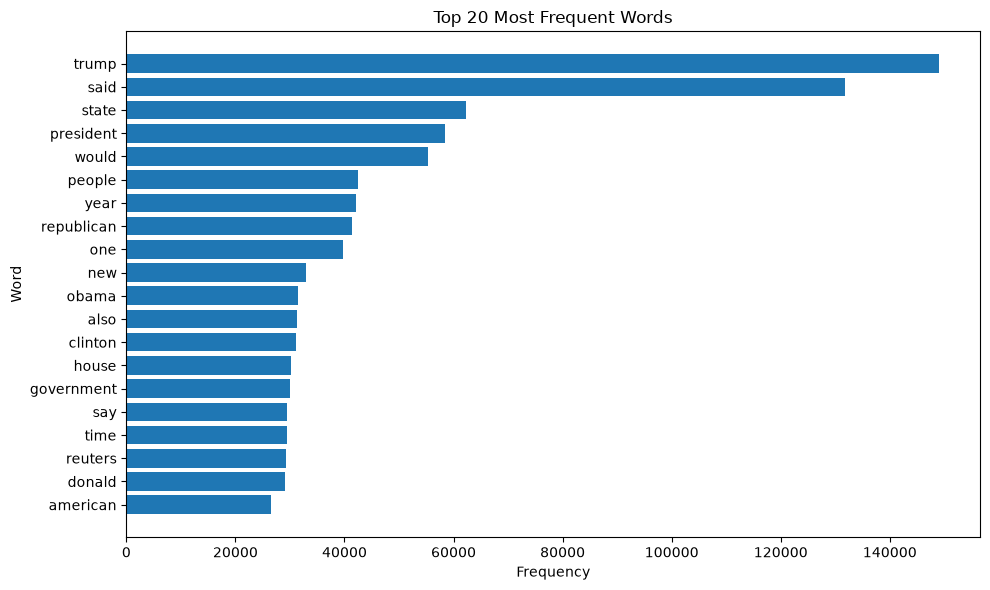

In [25]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_words["Word"][::-1],
    top_words["Frequency"][::-1]
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

## 9. Preparing Features and Labels

The cleaned news content is used as the input feature. The label column is used as the target:

- 0 = Fake News
- 1 = Real News

In [26]:
X = df["cleaned_content"]
y = df["label"]

print("Number of input records:", len(X))
print("Number of labels:", len(y))

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Number of input records: 44680
Number of labels: 44680

Target distribution:
label
0    23469
1    21211
Name: count, dtype: int64


## 10. Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

Stratified sampling is used to preserve the Fake and Real class distribution in both sets.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training records: 35744
Testing records: 8936

Training class distribution:
label
0    18775
1    16969
Name: count, dtype: int64

Testing class distribution:
label
0    4694
1    4242
Name: count, dtype: int64
